# Processed vs Unprocessed Comparison

Executed comparison notebook for the v2 ablation grid.

,variant,processed_best,processed_mode,processed_image_model,processed_tabular_model,combined_score_processed,test_acc_processed,test_bacc_processed,test_auc_processed,test_f1_macro_processed,...,combined_score_unprocessed,test_acc_unprocessed,test_bacc_unprocessed,test_auc_unprocessed,test_f1_macro_unprocessed,combined_score_delta,test_acc_delta,test_bacc_delta,test_auc_delta,test_f1_macro_delta
1,feature_selection,sota_best,late_fusion,sota,multi_expert,0.714942,73.043478,63.864423,0.934546,0.646804,...,0.733849,75.652174,64.490063,0.946659,0.670621,-0.018907,-2.608696,-0.625640,-0.012114,-0.023817
0,default_balanced,sota_best,late_fusion,sota,multi_expert,0.762361,78.695652,71.308654,0.928205,0.715513,...,0.790701,78.260870,73.750307,0.959648,0.728350,-0.028340,0.434783,-2.441652,-0.031444,-0.012837
2,no_imbalance,sota_best,late_fusion,sota,multi_expert,0.746468,77.826087,67.534577,0.942155,0.690323,...,0.786056,77.826087,73.066981,0.949704,0.737664,-0.039587,0.000000,-5.532403,-0.007549,-0.047341


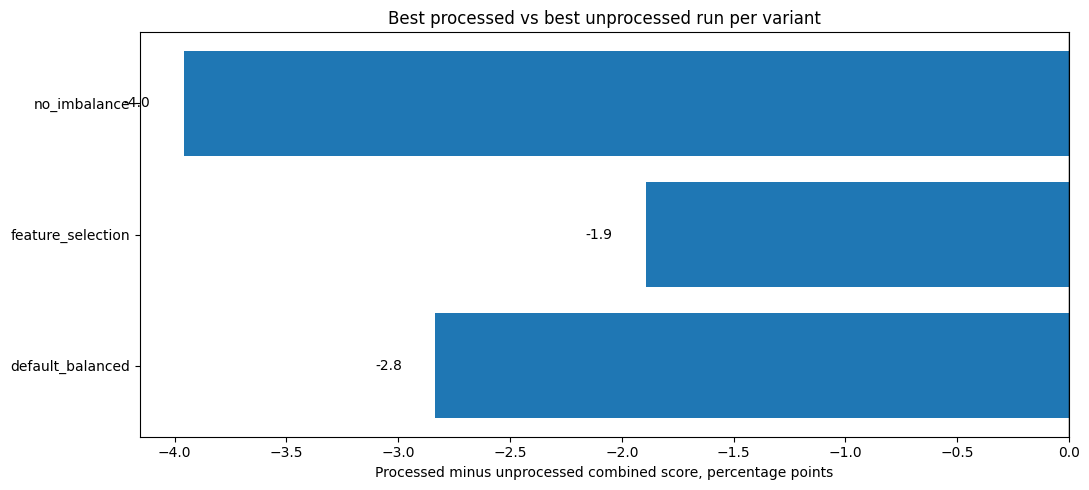

saved /home/zeus/content/IOT_fusion/Results_Figures/compare_best_processed_vs_unprocessed_combined_delta.png


In [1]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "Results_Logs" / "ablation_summary.csv").exists():
    ROOT = ROOT.parent
summary = pd.read_csv(ROOT / "Results_Logs" / "ablation_summary.csv")
metric_cols = ["test_acc", "test_bacc", "test_auc", "test_f1_macro"]
metric_labels = {
    "test_acc": "Accuracy (%)",
    "test_bacc": "Balanced accuracy (%)",
    "test_auc": "AUC (%)",
    "test_f1_macro": "Macro-F1 (%)",
    "combined_score": "Combined score (%)",
}
summary["combined_score"] = (
    0.35 * summary["test_f1_macro"].astype(float)
    + 0.25 * (summary["test_bacc"].astype(float) / 100.0)
    + 0.25 * summary["test_auc"].astype(float)
    + 0.10 * (summary["test_acc"].astype(float) / 100.0)
    + 0.05
    * (
        1.0
        / (
            1.0
            + summary["final_val_loss"].astype(float)
            + (summary["final_val_loss"].astype(float) - summary["final_train_loss"].astype(float)).abs()
        )
    )
)

def best_per_track(df):
    # Return one winner per dataset source and variant for compact comparisons.
    return (
        df.sort_values(["combined_score", "test_f1_macro", "test_bacc", "test_auc", "test_acc"], ascending=[False, False, False, False, False])
        .groupby(["dataset_source", "variant"], as_index=False)
        .head(1)
        .sort_values(["dataset_source", "variant"])
        .reset_index(drop=True)
    )

def metric_to_percent(series, metric):
    values = series.astype(float).copy()
    if metric in {"test_auc", "test_f1_macro"}:
        values = values * 100.0
    return values

def plot_metric_bars(df, title, out_name):
    data = df.sort_values("combined_score", ascending=False).copy()
    labels = data["dataset_source"] + " / " + data["variant"] + " / " + data["experiment_name"]
    fig_h = max(4.8, 0.72 * len(data) + 2.0)
    fig, axes = plt.subplots(3, 2, figsize=(13, max(fig_h, 7.0)))
    for ax, metric in zip(axes.ravel(), ["combined_score", *metric_cols]):
        values = metric_to_percent(data[metric], metric)
        ax.barh(labels, values)
        ax.invert_yaxis()
        ax.set_title(metric_labels[metric])
        ax.set_xlabel("Score; higher is better")
        ax.set_xlim(max(0, values.min() - 5), min(100, values.max() + 5))
        for y, value in enumerate(values):
            ax.text(value + 0.35, y, f"{value:.1f}", va="center", fontsize=8)
    axes.ravel()[-1].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    out = ROOT / "Results_Figures" / out_name
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=160)
    plt.show()
    print(f"saved {out}")

processed = best_per_track(summary[summary["dataset_source"] == "processed"]).copy()
unprocessed = best_per_track(summary[summary["dataset_source"] == "unprocessed"]).copy()
processed = processed[["variant", "experiment_name", "mode", "image_model", "tabular_model", "combined_score", *metric_cols]].rename(
    columns={
        "experiment_name": "processed_best",
        "mode": "processed_mode",
        "image_model": "processed_image_model",
        "tabular_model": "processed_tabular_model",
    }
)
unprocessed = unprocessed[["variant", "experiment_name", "mode", "image_model", "tabular_model", "combined_score", *metric_cols]].rename(
    columns={
        "experiment_name": "unprocessed_best",
        "mode": "unprocessed_mode",
        "image_model": "unprocessed_image_model",
        "tabular_model": "unprocessed_tabular_model",
    }
)
merged = processed.merge(unprocessed, on="variant", suffixes=("_processed", "_unprocessed"))
for metric in ["combined_score", *metric_cols]:
    merged[f"{metric}_delta"] = merged[f"{metric}_processed"] - merged[f"{metric}_unprocessed"]
display(merged.sort_values("combined_score_delta", ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
labels = merged["variant"]
delta = merged["combined_score_delta"] * 100.0
ax.barh(labels, delta)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Processed minus unprocessed combined score, percentage points")
ax.set_title("Best processed vs best unprocessed run per variant")
for y, value in enumerate(delta):
    ax.text(value + (0.15 if value >= 0 else -0.15), y, f"{value:+.1f}", va="center", ha="left" if value >= 0 else "right")
fig.tight_layout()
out = ROOT / "Results_Figures" / "compare_best_processed_vs_unprocessed_combined_delta.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=160)
plt.show()
print(f"saved {out}")
